# Eccentricity Effect on the PhotoRing Signal for a Ringless Planet

This notebook investigates how orbital eccentricity ($e$) affects the apparent **PhotoRing effect** for a planet *with no rings*.

The PhotoRing effect measures the ratio of the **observed** stellar density (derived from the transit light curve) to the **true** stellar density. For a circular orbit and no ring, this ratio should be $\approx 1$. Any deviation can be misinterpreted as a ring signature.

When $e > 0$, the planet velocity at transit changes (via $r_{\rm cen}$), distorting contact times and making the inferred density differ from the true density, even without any ring.

**Metric used:** Seager & Mallén-Ornelas (2003) approximation:
$$
\rho_{\rm obs} = \frac{3\pi}{G P^2} \left[ \frac{2P p^{1/4}}{\pi \sqrt{t_T^2 - t_F^2}} \right]^3
$$
where $p = (R_p/R_\star)^2$ is the transit depth, $t_T$ is the total transit duration, and $t_F$ is the flat-bottom duration.

**All calculations use `geotrans2.py`.**

## 1. Setup

In [1]:
# Standard imports
import warnings
warnings.filterwarnings('ignore')
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# geotrans2 provides all physics routines
# Make sure this notebook is run from the GeoTrans directory
from geotrans2 import (
    RingedSystem, contactTimes, ringedPlanetArea,
    fluxLimbTime, rhoObserved_Seager, rhoObserved_Kipping,
    HOUR, DEG, RAD, MINUTE, TAB
)

print("geotrans2 loaded successfully.")

geotrans2 loaded successfully.


## 2. Reference System Definition

We create a baseline **ringless planet** system. The key setting is `tau=0` (zero ring opacity), which suppresses any ring contribution to the transit area. We also set `fe=1` so the ring coincides with the planet.

All other parameters use the `geotrans2` defaults (Solar-like star, Saturn-like planet, 1 AU orbit).

In [ ]:
# Create baseline ringless system (circular orbit, e=0)
S0 = RingedSystem()

# Make it ringless: zero opacity and ring = planet size
S0.noauto = True
S0.tau  = 0.0         # No ring opacity
S0.fe   = 1.0*0       # Exterior ring radius = planet radius (no ring)
S0.fi   = 0.8         # Interior ring radius (irrelevant when tau=0)
S0.ep   = 0.0         # Circular orbit
S0.noauto = False
S0.updateSystem()

print("=== Baseline system (e=0, ringless) ===")
print(f"  Orbital eccentricity  ep   = {S0.ep}")
print(f"  Ring opacity          tau  = {S0.tau}")
print(f"  Ext ring factor       fe   = {S0.fe}")
print(f"  Planet radius (Rstar) Rp   = {S0.Rp:.5f}")
print(f"  Impact parameter      B    = {S0.Borb:.4f}")
print(f"  Orbital period        Porb = {S0.Porb/HOUR:.2f} h")
print(f"  Distance at transit   rcen = {S0.rcen:.4e} m")
print(f"  True stellar density  rho* = {S0.rho_true:.2f} kg/m^3")

=== Baseline system (e=0, ringless) ===
  Orbital eccentricity  ep   = 0.0
  Ring opacity          tau  = 0.0
  Ext ring factor       fe   = 1.0
  Planet radius (Rstar) Rp   = 0.08363
  Impact parameter      B    = 0.0000
  Orbital period        Porb = 8764.60 h
  Distance at transit   rcen = 1.4960e+11 m
  True stellar density  rho* = 1405.98 kg/m^3


## 3. Eccentricity Scan

We sweep over a range of eccentricities $e \in [0, 0.8]$ and for each value we:
1. Compute contact times $t_1, t_2, t_3, t_4$
2. Derive $t_T = t_4 - t_1$ (total duration) and $t_F = t_3 - t_2$ (flat duration)
3. Compute the transit depth $p = (R_p/R_\star)^2$
4. Compute $\rho_{\rm obs}$ via the Seager formula
5. Compute the **PhotoRing ratio** $\rho_{\rm obs}/\rho_\star$

By construction (no rings), any deviation from 1 is caused purely by eccentricity.

In [ ]:
# Eccentricity grid
eccentricities = np.linspace(0.0, 0.8, 30)

# Storage
results = []

print("Running eccentricity scan...")
print(f"{'e':>6}  {'tT (h)':>10}  {'tF (h)':>10}  {'rho_obs':>14}  {'rho_obs/rho*':>14}")
print("-" * 60)

for ep in eccentricities:
    # Clone and set eccentricity
    S = RingedSystem()
    S.noauto = True
    S.tau  = 0.0
    S.fe   = 1.0*0
    S.fi   = 0.8
    S.ep   = ep
    S.noauto = False
    S.updateSystem()

    # Contact times
    try:
        tcen, t1, t2, t3, t4 = contactTimes(S)
    except Exception as ex:
        print(f"  e={ep:.3f}  -> SKIPPED ({ex})")
        continue

    # Durations in hours
    tT = (t4 - t1) / HOUR
    tF = (t3 - t2) / HOUR
    P_h = S.Porb / HOUR

    # Transit depth (ringless planet)
    p = S.Rp ** 2

    # Observed stellar density
    rho_obs = rhoObserved_Seager(p, S.Rstar, tT, tF, P_h)
    ratio   = rho_obs / S.rho_true

    results.append(dict(
        ep=ep, tT=tT, tF=tF,
        rho_obs=rho_obs, ratio=ratio,
        rcen=S.rcen, Borb=S.Borb,
        Porb_h=P_h, p=p, S=S,
        tcen=tcen, t1=t1, t2=t2, t3=t3, t4=t4
    ))
    print(f"  {ep:6.3f}  {tT:10.4f}  {tF:10.4f}  {rho_obs:14.2f}  {ratio:14.6f}")

print("\nDone.")

Running eccentricity scan...
     e      tT (h)      tF (h)         rho_obs    rho_obs/rho*
------------------------------------------------------------
   0.000     14.0722     11.9002         1406.35        1.000264
   0.028     14.0667     11.8956         1407.98        1.001420
   0.055     14.0505     11.8819         1412.86        1.004888
   0.083     14.0236     11.8591         1421.02        1.010692
   0.110     13.9859     11.8272         1432.54        1.018890
   0.138     13.9373     11.7862         1447.56        1.029572
   0.166     13.8779     11.7359         1466.25        1.042863
   0.193     13.8073     11.6762         1488.83        1.058928
   0.221     13.7255     11.6071         1515.61        1.077971
   0.248     13.6323     11.5282         1546.93        1.100248
   0.276     13.5273     11.4394         1583.23        1.126068
   0.303     13.4102     11.3404         1625.05        1.155810
   0.331     13.2808     11.2310         1673.02        1.189931
  

## 4. PhotoRing Ratio vs. Eccentricity

The "PhotoRing ratio" $\rho_{\rm obs}/\rho_\star$ quantifies how much the inferred stellar density deviates from the true value. For a circular orbit and no ring, the ratio is 1. Orbital eccentricity introduces a systematic bias even without a ring.

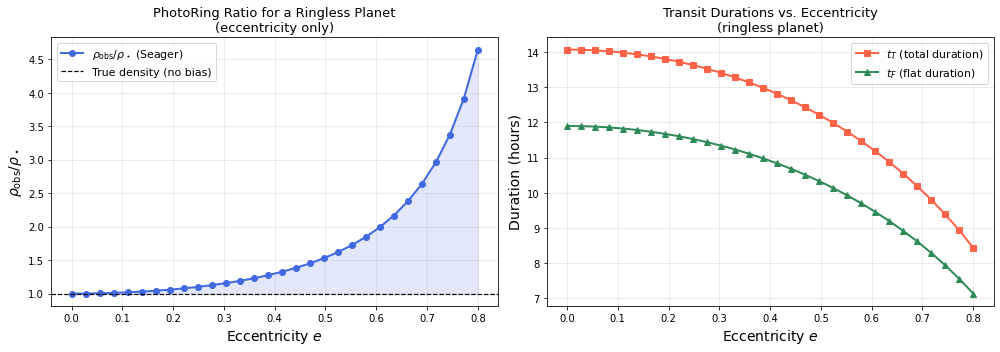

Figure saved to figures/ringless_eccentricity_photoring.png


In [4]:
eps    = np.array([r['ep']    for r in results])
ratios = np.array([r['ratio'] for r in results])
tTs    = np.array([r['tT']    for r in results])
tFs    = np.array([r['tF']    for r in results])
rcens  = np.array([r['rcen']  for r in results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: rho_obs / rho_true ---
ax = axes[0]
ax.plot(eps, ratios, 'o-', color='royalblue', lw=2, ms=6, label=r'$\rho_{\rm obs}/\rho_\star$ (Seager)')
ax.axhline(1.0, color='k', ls='--', lw=1.2, label='True density (no bias)')
ax.fill_between(eps, 1, ratios, alpha=0.15, color='royalblue')
ax.set_xlabel(r'Eccentricity $e$', fontsize=14)
ax.set_ylabel(r'$\rho_{\rm obs} / \rho_\star$', fontsize=14)
ax.set_title('PhotoRing Ratio for a Ringless Planet\n(eccentricity only)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- Right: Transit durations ---
ax2 = axes[1]
ax2.plot(eps, tTs, 's-', color='tomato',   lw=2, ms=6, label=r'$t_T$ (total duration)')
ax2.plot(eps, tFs, '^-', color='seagreen', lw=2, ms=6, label=r'$t_F$ (flat duration)')
ax2.set_xlabel(r'Eccentricity $e$', fontsize=14)
ax2.set_ylabel('Duration (hours)', fontsize=14)
ax2.set_title('Transit Durations vs. Eccentricity\n(ringless planet)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('figures/ringless_eccentricity_photoring.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to figures/ringless_eccentricity_photoring.png")

## 5. Log-scale PhotoRing Ratio

Following the convention in the literature, we plot $\log_{10}(\rho_{\rm obs}/\rho_\star)$ to make it easier to compare with the ringed-planet contour maps.

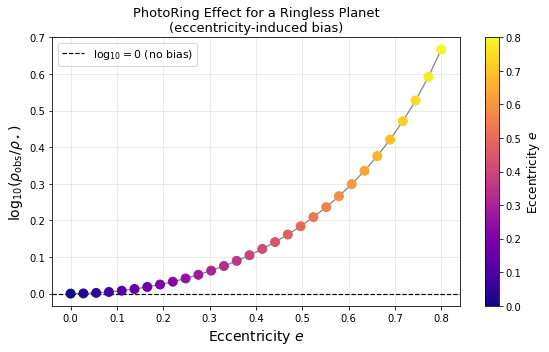

In [5]:
log_ratios = np.log10(ratios)

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(eps, log_ratios, c=eps, cmap='plasma', s=80, zorder=3)
ax.plot(eps, log_ratios, '-', color='gray', lw=1.2, zorder=2)
ax.axhline(0.0, color='k', ls='--', lw=1.2, label=r'$\log_{10}=0$ (no bias)')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'Eccentricity $e$', fontsize=12)

ax.set_xlabel(r'Eccentricity $e$', fontsize=14)
ax.set_ylabel(r'$\log_{10}(\rho_{\rm obs}/\rho_\star)$', fontsize=14)
ax.set_title('PhotoRing Effect for a Ringless Planet\n(eccentricity-induced bias)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('figures/ringless_eccentricity_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Transit Light Curves for Selected Eccentricities

We visualize how the light curve shape changes with eccentricity for the same ringless planet, using `fluxLimbTime` which integrates limb-darkening over the transit.

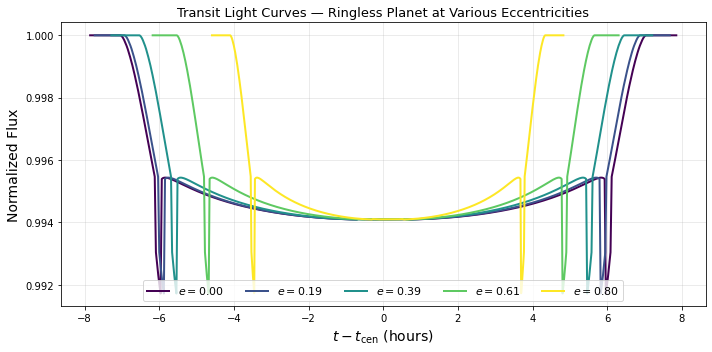

In [6]:
# Select a subset of eccentricities for light curve comparison
ecc_select = [0.0, 0.2, 0.4, 0.6, 0.8]
colors = plt.cm.viridis(np.linspace(0, 1, len(ecc_select)))

fig, ax = plt.subplots(figsize=(10, 5))

for ep_val, color in zip(ecc_select, colors):
    # Find the result closest to this eccentricity
    r = min(results, key=lambda r: abs(r['ep'] - ep_val))
    S = r['S']
    Ar = ringedPlanetArea(S)
    tcen = r['tcen']
    t1, t4 = r['t1'], r['t4']

    # Time array centered on transit
    margin = 1.5 * S.dtplanet
    t_arr = np.linspace(t1 - margin, t4 + margin, 500)

    # Compute normalized flux
    flux = np.array([fluxLimbTime(t, Ar, S) for t in t_arr])

    # Plot vs. hours from center
    ax.plot((t_arr - tcen) / HOUR, flux,
            color=color, lw=2,
            label=f'$e={r["ep"]:.2f}$')

ax.set_xlabel(r'$t - t_{\rm cen}$ (hours)', fontsize=14)
ax.set_ylabel('Normalized Flux', fontsize=14)
ax.set_title('Transit Light Curves — Ringless Planet at Various Eccentricities', fontsize=13)
ax.legend(fontsize=11, loc='lower center', ncol=len(ecc_select))
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('figures/ringless_lightcurves_ecc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Physical Interpretation: Orbital Distance at Transit

The key physical driver is $r_{\rm cen}$, the orbital radius at the time of central transit. For an eccentric orbit, the planet is not at $a$ when it transits, which changes the transit velocity and hence contact times. The formula:

$$r_{\rm cen} = \frac{a(1-e^2)}{1 + e\cos f_{\rm cen}}
\quad \text{where} \quad f_{\rm cen} = 270^\circ - \omega$$

We explore how $r_{\rm cen}$ and the resulting transit speed affect the PhotoRing ratio.

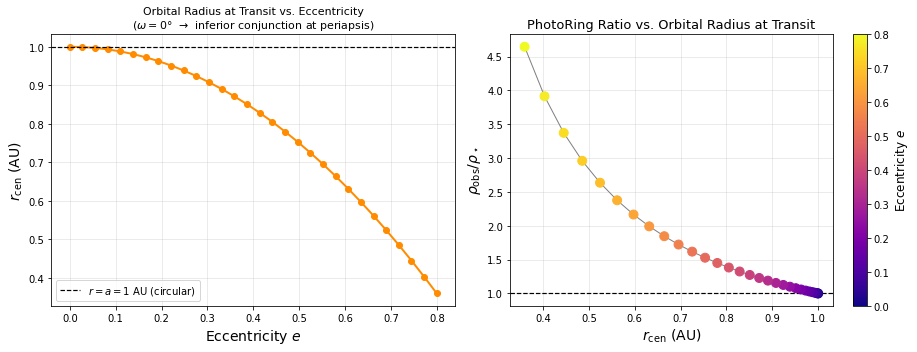

In [7]:
from geotrans2 import AU  # Semi-major axis unit

rcens_au = rcens / AU

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# rcen vs e
ax = axes[0]
ax.plot(eps, rcens_au, 'o-', color='darkorange', lw=2, ms=6)
ax.axhline(1.0, color='k', ls='--', lw=1.2, label='$r = a = 1$ AU (circular)')
ax.set_xlabel(r'Eccentricity $e$', fontsize=14)
ax.set_ylabel(r'$r_{\rm cen}$ (AU)', fontsize=14)
ax.set_title('Orbital Radius at Transit vs. Eccentricity\n($\omega = 0°$  →  inferior conjunction at periapsis)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# PhotoRing ratio vs rcen
ax2 = axes[1]
sc2 = ax2.scatter(rcens_au, ratios, c=eps, cmap='plasma', s=80, zorder=3)
ax2.plot(rcens_au, ratios, '-', color='gray', lw=1, zorder=2)
ax2.axhline(1.0, color='k', ls='--', lw=1.2)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label(r'Eccentricity $e$', fontsize=12)
ax2.set_xlabel(r'$r_{\rm cen}$ (AU)', fontsize=14)
ax2.set_ylabel(r'$\rho_{\rm obs}/\rho_\star$', fontsize=14)
ax2.set_title('PhotoRing Ratio vs. Orbital Radius at Transit', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('figures/ringless_rcen_photoring.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Argument of Periastron Dependence

The effect also depends on the argument of periastron $\omega$. When $\omega = 90°$ the transit occurs at periastron (fastest), when $\omega = 270°$ at apastron (slowest). We scan $\omega$ at fixed $e = 0.5$.

In [8]:
from geotrans2 import DEG

ep_fixed  = 0.5
omega_vals = np.linspace(0, 360, 73)  # degrees

wp_results = []
print(f"Scanning omega at e={ep_fixed} (fixed)...")

for wp_deg in omega_vals:
    wp_rad = wp_deg * DEG
    S = RingedSystem()
    S.noauto = True
    S.tau  = 0.0
    S.fe   = 1.0
    S.fi   = 0.8
    S.ep   = ep_fixed
    S.wp   = wp_rad
    S.noauto = False
    try:
        S.updateSystem()
    except SystemExit:
        # No transit for this configuration
        continue

    try:
        tcen, t1, t2, t3, t4 = contactTimes(S)
    except Exception:
        continue

    tT = (t4 - t1) / HOUR
    tF = (t3 - t2) / HOUR
    P_h = S.Porb / HOUR
    p = S.Rp ** 2

    if tT <= 0 or tF <= 0 or tT <= tF:
        continue

    rho_obs = rhoObserved_Seager(p, S.Rstar, tT, tF, P_h)
    ratio   = rho_obs / S.rho_true

    wp_results.append(dict(wp=wp_deg, ratio=ratio, log_ratio=np.log10(ratio),
                           tT=tT, tF=tF, rcen=S.rcen/AU, Borb=S.Borb))

print(f"Valid configurations: {len(wp_results)} / {len(omega_vals)}")

Scanning omega at e=0.5 (fixed)...
Valid configurations: 60 / 73


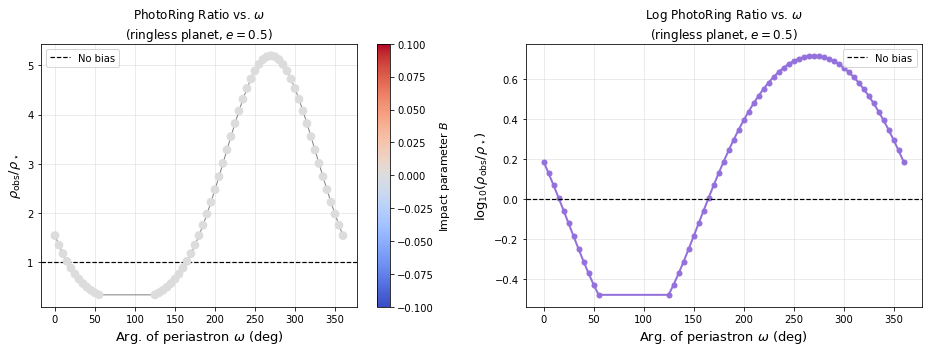

In [9]:
wps         = np.array([r['wp']        for r in wp_results])
wp_ratios   = np.array([r['ratio']     for r in wp_results])
wp_log_rats = np.array([r['log_ratio'] for r in wp_results])
wp_Borbs    = np.array([r['Borb']      for r in wp_results])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(wps, wp_ratios, c=wp_Borbs, cmap='coolwarm', s=60, zorder=3)
ax.plot(wps, wp_ratios, '-', color='gray', lw=1, zorder=2)
ax.axhline(1.0, color='k', ls='--', lw=1.2, label='No bias')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Impact parameter $B$', fontsize=11)
ax.set_xlabel(r'Arg. of periastron $\omega$ (deg)', fontsize=13)
ax.set_ylabel(r'$\rho_{\rm obs}/\rho_\star$', fontsize=13)
ax.set_title(f'PhotoRing Ratio vs. $\omega$\n(ringless planet, $e={ep_fixed}$)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(wps, wp_log_rats, 'o-', color='mediumpurple', lw=2, ms=5)
ax2.axhline(0.0, color='k', ls='--', lw=1.2, label='No bias')
ax2.set_xlabel(r'Arg. of periastron $\omega$ (deg)', fontsize=13)
ax2.set_ylabel(r'$\log_{10}(\rho_{\rm obs}/\rho_\star)$', fontsize=13)
ax2.set_title(f'Log PhotoRing Ratio vs. $\omega$\n(ringless planet, $e={ep_fixed}$)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('figures/ringless_omega_photoring.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 2D Map: PhotoRing Ratio in the $(e, \omega)$ Plane

A comprehensive view: the **PhotoRing ratio** as a function of both eccentricity and argument of periastron for a ringless planet.

In [10]:
ep_grid = np.linspace(0.0, 0.7, 20)
wp_grid = np.linspace(0.0, 360, 36)  # degrees

LOG_RATIO_MAP = np.full((len(ep_grid), len(wp_grid)), np.nan)

print("Building 2D (e, omega) map...")
for i, ep_val in enumerate(ep_grid):
    for j, wp_deg in enumerate(wp_grid):
        S = RingedSystem()
        S.noauto = True
        S.tau  = 0.0
        S.fe   = 1.0
        S.fi   = 0.8
        S.ep   = ep_val
        S.wp   = wp_deg * DEG
        S.noauto = False
        try:
            S.updateSystem()
        except SystemExit:
            continue
        try:
            tcen, t1, t2, t3, t4 = contactTimes(S)
        except Exception:
            continue

        tT = (t4 - t1) / HOUR
        tF = (t3 - t2) / HOUR
        if tT <= 0 or tF <= 0 or tT <= tF:
            continue

        P_h = S.Porb / HOUR
        p   = S.Rp ** 2
        rho_obs = rhoObserved_Seager(p, S.Rstar, tT, tF, P_h)
        LOG_RATIO_MAP[i, j] = np.log10(rho_obs / S.rho_true)

print("Done.")

Building 2D (e, omega) map...
Done.


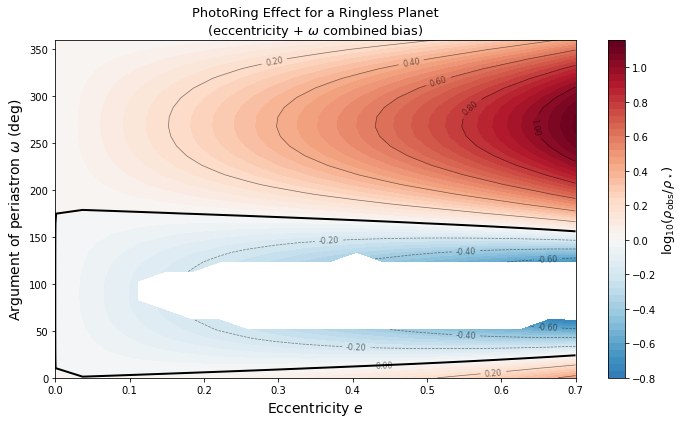

In [11]:
EP_GRID, WP_GRID = np.meshgrid(ep_grid, wp_grid, indexing='ij')

fig, ax = plt.subplots(figsize=(10, 6))

vmax = np.nanmax(np.abs(LOG_RATIO_MAP))
vmin = -vmax

im = ax.contourf(ep_grid, wp_grid, LOG_RATIO_MAP.T,
                 levels=50, cmap='RdBu_r', vmin=vmin, vmax=vmax)

cs = ax.contour(ep_grid, wp_grid, LOG_RATIO_MAP.T,
                levels=10, colors='k', linewidths=0.7, alpha=0.5)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

# Mark the zero contour (no bias)
ax.contour(ep_grid, wp_grid, LOG_RATIO_MAP.T,
           levels=[0], colors=['k'], linewidths=[2], linestyles=['-'])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$\log_{10}(\rho_{\rm obs}/\rho_\star)$', fontsize=13)

ax.set_xlabel(r'Eccentricity $e$', fontsize=14)
ax.set_ylabel(r'Argument of periastron $\omega$ (deg)', fontsize=14)
ax.set_title('PhotoRing Effect for a Ringless Planet\n'
             r'(eccentricity + $\omega$ combined bias)', fontsize=13)

plt.tight_layout()
# plt.savefig('figures/ringless_2d_photoring_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Statistics

Print a handy summary table with the key metrics across eccentricities.

In [12]:
print(f"{'e':>6} | {'tT (h)':>8} | {'tF (h)':>8} | "
      f"{'rcen/a':>8} | {'rho_obs/rho*':>13} | {'log10 ratio':>12}")
print("-" * 72)

from geotrans2 import AU
for r in results:
    S_ref = r['S']
    rcen_a = r['rcen'] / S_ref.ap   # in units of semi-major axis
    print(f"  {r['ep']:5.3f} | {r['tT']:8.4f} | {r['tF']:8.4f} | "
          f"  {rcen_a:6.4f} | {r['ratio']:13.6f} | {np.log10(r['ratio']):12.6f}")

     e |   tT (h) |   tF (h) |   rcen/a |  rho_obs/rho* |  log10 ratio
------------------------------------------------------------------------
  0.000 |  14.0722 |  11.9002 |   1.0000 |      1.000264 |     0.000115
  0.028 |  14.0667 |  11.8956 |   0.9992 |      1.001420 |     0.000616
  0.055 |  14.0505 |  11.8819 |   0.9970 |      1.004888 |     0.002118
  0.083 |  14.0236 |  11.8591 |   0.9932 |      1.010692 |     0.004619
  0.110 |  13.9859 |  11.8272 |   0.9878 |      1.018890 |     0.008127
  0.138 |  13.9373 |  11.7862 |   0.9810 |      1.029572 |     0.012657
  0.166 |  13.8779 |  11.7359 |   0.9726 |      1.042863 |     0.018227
  0.193 |  13.8073 |  11.6762 |   0.9627 |      1.058928 |     0.024866
  0.221 |  13.7255 |  11.6071 |   0.9513 |      1.077971 |     0.032607
  0.248 |  13.6323 |  11.5282 |   0.9384 |      1.100248 |     0.041490
  0.276 |  13.5273 |  11.4394 |   0.9239 |      1.126068 |     0.051565
  0.303 |  13.4102 |  11.3404 |   0.9079 |      1.155810 |     0

## 11. Conclusions

- For a **ringless planet on a circular orbit** ($e=0$, $\omega=0°$), the PhotoRing ratio $\rho_{\rm obs}/\rho_\star \approx 1$ — no spurious ring signal.
- Increasing **eccentricity** shifts the orbital radius at transit ($r_{\rm cen} \neq a$), changing the planet velocity and hence the transit duration. This introduces a **systematic bias** in the Seager density estimate.
- The sign and magnitude of the bias depend strongly on $\omega$: transit near **periastron** ($\omega \approx 90°$) speeds up the transit (shorter $t_T$, higher $\rho_{\rm obs}$); transit near **apastron** ($\omega \approx 270°$) slows the transit (longer $t_T$, lower $\rho_{\rm obs}$).
- The 2D map in Sec. 9 provides a complete picture: for a **ringless planet**, eccentricity alone can produce $|\log_{10}(\rho_{\rm obs}/\rho_\star)| \sim 0.5$–$1$, comparable to a ring signal.
- **Implication:** for eccentric transiting systems, eccentricity must be accurately constrained before claiming a PhotoRing detection.